## Perceptron with offset
In the previous notebook, the decision boundary was through the origin point (0,0). In this notebook we extend the example to show how the Perceptron algorithn can be modified to help find a decsion boundary that doesn't run through the origin.

In [1]:
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
%matplotlib inline

#### Data Setup
As before, create some mock data of different categories that are separable by a straight line. Plot these on a graph. We just use diffeerent colours to show two different cateogries - red and blue. It's pretty obvious to the human eye were the decision boundary should be to separate the blue and red points, but we want this decisoin boundary to be found by the Perceptron algorithm.

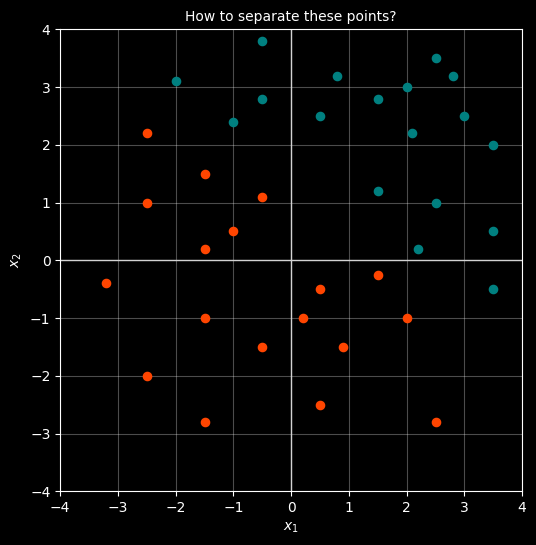

In [14]:
# More points: teal above/right of boundary, red below/left
blue_pts = np.array([
    [ 2.0,  3.0],
    [ 3.0,  2.5],
    [ 2.5,  3.5],
    [ 3.5,  2.0],
    [ 1.5,  2.8],
    [ 2.8,  3.2],
    [-2, 3.1],
    [-1, 2.4],
    [-0.5, 3.8],
    [2.5, 1.0],
    [3.5, 0.5],
    [0.5, 2.5],
    [1.5, 1.2],
    [2.1, 2.2],
    [3.5, -0.5],
    [0.8, 3.2],
    [-0.5, 2.8],
    [2.2, 0.2]
])

red_pts = np.array([
    [-0.5, 1.1],
    [-1.0,  0.5],
    [-2.5,  1.0],
    [ 0.5, -0.5],
    [-1.5,  0.2],
    [ 0.2, -1.0],
    [-1.5, 1.5],
    [-2.5, 2.2],
    [-1.5, -1],
    [-0.5, -1.5],
    [2,-1],
    [1.5, -.25],
    [0.9, -1.5],
    [-2.5, -2],
    [-3.2, -0.4],
    [-1.5, -2.8],
    [2.5, -2.8],
    [0.5, -2.5]
])


with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # plot points
    ax.scatter(blue_pts[:,0], blue_pts[:,1], s=35, color="teal", zorder=3)
    ax.scatter(red_pts[:,0],  red_pts[:,1],  s=35, color="orangered", zorder=3)
    
    
    # axes + grid
    ax.axhline(0, color="lightgray", linewidth=1)
    ax.axvline(0, color="lightgray", linewidth=1)

    
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"How to separate these points?", fontsize="10")
    
    plt.show()

#### Key Perceptron functions
These two functions implement the core of the Perceptron algorithm. The first evaluates the current weight vector $W$ against each vector $x$ to see if $W$ correctly classifies $x$. Note that the dimension of $W$ is one more than in the previous notebook because it includes a bias term controlling how far the decision boundary is offset from the origin. Wihout the bias term, the boundary would always be forced to pass through the origin.

The second function updates $W$ in the case of an incorrect classification.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate(W, x):
    """
    Calculate the dot product of W and x (including bias term).
    Return 1 if the result is >= 0, else -1.
    """
    dot_prod = np.dot(W, x)
    return 1 if dot_prod >= 0 else -1

def update(W, x, y_label, learning_rate=0.1):
    """
    Update W by adding the misclassified vector (including bias) scaled by its label.
    Returns the updated W.
    """
    W = W + learning_rate * y_label * x
    return W

#### Helper functions
These log the results of the current iteration and plot the current decision boundary and Weights vector.

In [37]:
def print_status(epoch, W_before, W_after, predictions):
    """Print the classification results for a given epoch."""
    misclassifications = sum(p != yi for p, yi in zip(predictions, y))
    status_msg = "Misclassifications found" if misclassifications > 0 else "No misclassifications found"

    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1} - {status_msg}")
    print(f"{'='*70}")
    print(f"W before: {np.round(W_before[:2], 3)}  \t Bias before: {round(W_before[2], 3)}")
    print(f"W after:  {np.round(W_after[:2], 3)}  \t Bias after:  {round(W_after[2], 3)}")
    print(f"Total misclassifications: {misclassifications}\n")

    print(f"{'Idx':<5} {'Point':<22} {'Actual':<10} {'Predicted':<10} {'Status':<10}")
    print("-" * 60)
    for idx, (xi, yi, pred) in enumerate(zip(X, y, predictions)):
        actual_label = "blue" if yi   == 1 else "red"
        pred_label   = "blue" if pred == 1 else "red"
        status       = "✓ CORRECT" if pred == yi else "✗ WRONG"
        print(f"{idx:<5} {str(xi[:2]):<22} {actual_label:<10} {pred_label:<10} {status:<10}")

    if misclassifications == 0:
        print("\n✓ NO MISCLASSIFICATIONS - CONVERGED!")


def plot_decision_boundary(W, epoch):
    """Plot the data points, decision boundary and weight vector for a given W."""
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(5, 5))

        ax.scatter(blue_pts[:, 0], blue_pts[:, 1], s=25, color="lightblue", zorder=3)
        ax.scatter(red_pts[:, 0],  red_pts[:, 1],  s=25, color="orangered", zorder=3)

        x_range = np.linspace(-5, 5, 100)
        if abs(W[1]) > 0.01:
            x2_boundary = -(W[0] * x_range + W[2]) / W[1]
            ax.plot(x_range, x2_boundary, color="yellow", linewidth=2)
        else:
            ax.axvline(-W[2] / W[0], color="yellow", linewidth=2)

        ax.arrow(0, 0, W[0], W[1],
                 length_includes_head=True,
                 head_width=0.15, head_length=0.2,
                 linewidth=2, color="fuchsia")

        ax.axhline(0, color="grey", linewidth=1)
        ax.axvline(0, color="grey", linewidth=1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(r"$x_1$", fontsize=9)
        ax.set_ylabel(r"$x_2$", fontsize=9)
        ax.set_title(f"Epoch {epoch + 1}: W = {np.round(W[:2], 2)}, b = {round(W[2], 2)}", fontsize=10)

        plt.tight_layout()
        plt.show()

#### Training loop
The training loop iterates through all points in $X$, evaluating each one against the current $W$. If a point is misclassified, $W$ is updated before moving on to the next point. One full pass through all points is called an **epoch**.

At the end of each epoch we check whether all points are correctly classified. If so, the algorithm has converged and we stop. If not, we run another epoch with the updated $W$. 


EPOCH 1 - Misclassifications found
W before: [0.5 0.5]  	 Bias before: 0.0
W after:  [0.2   0.515]  	 Bias after:  -0.3
Total misclassifications: 3

Idx   Point                  Actual     Predicted  Status    
------------------------------------------------------------
0     [2. 3.]                blue       blue       ✓ CORRECT 
1     [3.  2.5]              blue       blue       ✓ CORRECT 
2     [2.5 3.5]              blue       blue       ✓ CORRECT 
3     [3.5 2. ]              blue       blue       ✓ CORRECT 
4     [1.5 2.8]              blue       blue       ✓ CORRECT 
5     [2.8 3.2]              blue       blue       ✓ CORRECT 
6     [-2.   3.1]            blue       blue       ✓ CORRECT 
7     [-1.   2.4]            blue       blue       ✓ CORRECT 
8     [-0.5  3.8]            blue       blue       ✓ CORRECT 
9     [2.5 1. ]              blue       blue       ✓ CORRECT 
10    [3.5 0.5]              blue       blue       ✓ CORRECT 
11    [0.5 2.5]              blue       blue 

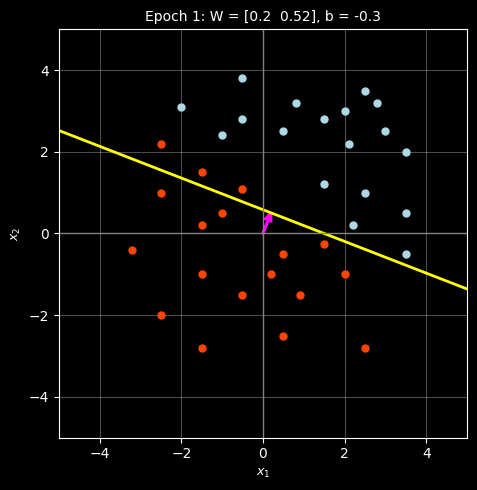


EPOCH 2 - Misclassifications found
W before: [0.2   0.515]  	 Bias before: -0.3
W after:  [0.25  0.405]  	 Bias after:  -0.4
Total misclassifications: 1

Idx   Point                  Actual     Predicted  Status    
------------------------------------------------------------
0     [2. 3.]                blue       blue       ✓ CORRECT 
1     [3.  2.5]              blue       blue       ✓ CORRECT 
2     [2.5 3.5]              blue       blue       ✓ CORRECT 
3     [3.5 2. ]              blue       blue       ✓ CORRECT 
4     [1.5 2.8]              blue       blue       ✓ CORRECT 
5     [2.8 3.2]              blue       blue       ✓ CORRECT 
6     [-2.   3.1]            blue       blue       ✓ CORRECT 
7     [-1.   2.4]            blue       blue       ✓ CORRECT 
8     [-0.5  3.8]            blue       blue       ✓ CORRECT 
9     [2.5 1. ]              blue       blue       ✓ CORRECT 
10    [3.5 0.5]              blue       blue       ✓ CORRECT 
11    [0.5 2.5]              blue       

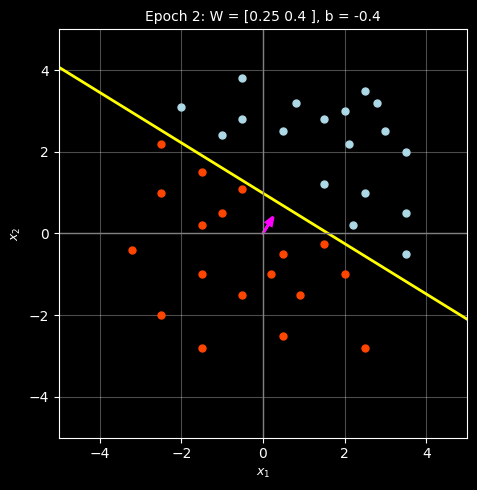


EPOCH 3 - No misclassifications found
W before: [0.25  0.405]  	 Bias before: -0.4
W after:  [0.25  0.405]  	 Bias after:  -0.4
Total misclassifications: 0

Idx   Point                  Actual     Predicted  Status    
------------------------------------------------------------
0     [2. 3.]                blue       blue       ✓ CORRECT 
1     [3.  2.5]              blue       blue       ✓ CORRECT 
2     [2.5 3.5]              blue       blue       ✓ CORRECT 
3     [3.5 2. ]              blue       blue       ✓ CORRECT 
4     [1.5 2.8]              blue       blue       ✓ CORRECT 
5     [2.8 3.2]              blue       blue       ✓ CORRECT 
6     [-2.   3.1]            blue       blue       ✓ CORRECT 
7     [-1.   2.4]            blue       blue       ✓ CORRECT 
8     [-0.5  3.8]            blue       blue       ✓ CORRECT 
9     [2.5 1. ]              blue       blue       ✓ CORRECT 
10    [3.5 0.5]              blue       blue       ✓ CORRECT 
11    [0.5 2.5]              blue    

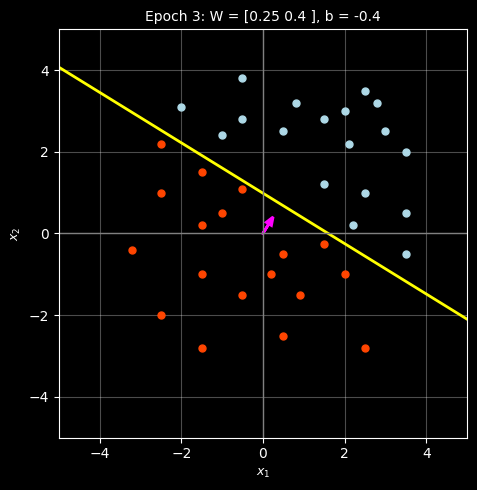


Converged after 3 epochs!
Final W: [0.25  0.405], Bias: -0.4


In [38]:
blue_pts = np.array([
    [ 2.0,  3.0],
    [ 3.0,  2.5],
    [ 2.5,  3.5],
    [ 3.5,  2.0],
    [ 1.5,  2.8],
    [ 2.8,  3.2],
    [-2.0,  3.1],
    [-1.0,  2.4],
    [-0.5,  3.8],
    [ 2.5,  1.0],
    [ 3.5,  0.5],
    [ 0.5,  2.5],
    [ 1.5,  1.2],
    [ 2.1,  2.2],
    [ 3.5, -0.5],
    [ 0.8,  3.2],
    [-0.5,  2.8],
    [ 2.2,  0.2]
])
red_pts = np.array([
    [-0.5,  1.1],
    [-1.0,  0.5],
    [-2.5,  1.0],
    [ 0.5, -0.5],
    [-1.5,  0.2],
    [ 0.2, -1.0],
    [-1.5,  1.5],
    [-2.5,  2.2],
    [-1.5, -1.0],
    [-0.5, -1.5],
    [ 2.0, -1.0],
    [ 1.5, -0.25],
    [ 0.9, -1.5],
    [-2.5, -2.0],
    [-3.2, -0.4],
    [-1.5, -2.8],
    [ 2.5, -2.8],
    [ 0.5, -2.5]
])

X = np.vstack([blue_pts, red_pts])
y = np.hstack([np.ones(len(blue_pts)), -np.ones(len(red_pts))])
X = np.hstack([X, np.ones((X.shape[0], 1))])

W = np.array([0.5, 0.5, 0.0])

for epoch in range(20):
    W_before = W.copy()
    predictions = []
    for xi, yi in zip(X, y):
        pred = evaluate(W, xi)
        predictions.append(pred)
        if pred != yi:
            W = update(W, xi, yi)

    print_status(epoch, W_before, W, predictions)
    plot_decision_boundary(W, epoch)

    if all(p == yi for p, yi in zip(predictions, y)):
        print(f"\nConverged after {epoch + 1} epochs!")
        print(f"Final W: {np.round(W[:2], 3)}, Bias: {round(W[2], 3)}")
        break